# PPO Single Episode Visualization

In [11]:
import os
import sys
sys.path.append('..')

import csv
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
from stable_baselines3 import PPO
from src.env import BusEnv

MODEL_PATH = '../model/ppo_agent.pth'
TARGET_STOPS = {0, 2, 7}

In [12]:
def load_agent(env, model_path):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found at {model_path}")

    # Stable Baselines 3 PPO saves a zip archive. Load it with PPO.load.
    if model_path.endswith('.pth') or model_path.endswith('.zip'):
        try:
            model = PPO.load(model_path, env=env)
            print(f"Loaded PPO model from {model_path}")
            return model
        except Exception as ppo_error:
            print('PPO load failed, falling back to PyTorch checkpoint loader:', ppo_error)

    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    agent = BusAgent(env)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        agent.main_q.load_state_dict(checkpoint['model_state_dict'])
    else:
        agent.main_q.load_state_dict(checkpoint)

    agent.main_q.eval()
    print(f"Loaded DQN agent from {model_path}")
    return agent

In [13]:
def run_episode(env, agent):
    logs = defaultdict(lambda: defaultdict(lambda: {"arr": [], "dep": []}))
    prev_stops = {}

    # NEW: time-series data
    stop_crowding = {}   # timestep -> list of queue lengths
    bus_occupancy = {}   # timestep -> {bus_id: occupancy}

    state, info = env.reset()
    done = False

    while not done:
                # PPO / Stable-Baselines3 agent
        if hasattr(agent, "predict"):
            action, _ = agent.predict(state, deterministic=True)

            if hasattr(action, "item"):
                action = action.item()

        # Custom DQN agent
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                q_values = agent.main_q(state_tensor)

            action = torch.argmax(q_values, dim=1).item()

        next_state, reward, terminated, truncated, info = env.step(action)
        timestep = info["timestep"]

        # --- NEW: record stop crowding ---
        stop_crowding[timestep] = env.unwrapped.queues.copy().tolist()

        # --- NEW: record bus occupancy ---
        bus_occupancy[timestep] = {}
        for i, bus in enumerate(env.unwrapped.buses):
            if bus["active"]:
                bus_occupancy[timestep][i] = bus["occupancy"]

        # --- EXISTING: arrival/departure logging ---
        for i, bus in enumerate(env.unwrapped.buses):
            if not bus["active"]:
                continue

            current_stop = bus["stop"]

            if i not in prev_stops:
                prev_stops[i] = current_stop
                continue

            prev_stop = prev_stops[i]

            if current_stop != prev_stop:
                if current_stop in TARGET_STOPS:
                    logs[i][current_stop]["arr"].append(timestep)

                if prev_stop in TARGET_STOPS:
                    logs[i][prev_stop]["dep"].append(timestep)

            prev_stops[i] = current_stop

        state = next_state
        done = terminated or truncated

    return logs, stop_crowding, bus_occupancy

In [14]:
def save_logs(logs, filename='agent-logs/ppo_episode_chart.csv'):
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['bus_id', 'stop', 'event', 'time'])

        for bus_id, stops in logs.items():
            for stop, data in stops.items():
                for t in data['arr']:
                    writer.writerow([bus_id, stop, 'arrival', t])
                for t in data['dep']:
                    writer.writerow([bus_id, stop, 'departure', t])

    print(f'Saved chart data to {filename}')



In [15]:

def plot_stop_crowding(stop_crowding, every_n_steps=10):
    timesteps = sorted(stop_crowding)

    sampled_timesteps = timesteps[::every_n_steps]

    queue_matrix = np.array([
        stop_crowding[t]
        for t in sampled_timesteps
    ])

    plt.figure(figsize=(14, 6))
    plt.imshow(queue_matrix.T, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Queue Length")

    tick_count = min(8, len(sampled_timesteps))
    tick_positions = np.linspace(0, len(sampled_timesteps) - 1, tick_count, dtype=int)

    tick_labels = [
        timestep_to_time_label(sampled_timesteps[i], start_hour=8, minutes_per_step=1)
        for i in tick_positions
    ]

    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.yticks(
        ticks=np.arange(queue_matrix.shape[1]),
        labels=[f"Stop {i}" for i in range(queue_matrix.shape[1])]
    )

    plt.xlabel("Time of Day")
    plt.ylabel("Stop")
    plt.title("Stop Crowding Over Time")
    plt.tight_layout()
    plt.show()


def timestep_to_time_label(timestep, start_hour=8, minutes_per_step=1):
    total_minutes = start_hour * 60 + timestep * minutes_per_step
    hour = (total_minutes // 60) % 24
    minute = total_minutes % 60
    return f"{hour:02d}:{minute:02d}"



In [16]:

def plot_total_bus_occupancy(bus_occupancy, window=30, start_hour=8, minutes_per_step=1):
    timesteps = sorted(bus_occupancy)

    total_occupancy = np.array([
        sum(bus_occupancy[t].values())
        for t in timesteps
    ], dtype=float)

    if len(total_occupancy) >= window:
        kernel = np.ones(window) / window
        smoothed = np.convolve(total_occupancy, kernel, mode="same")
    else:
        smoothed = total_occupancy

    plt.figure(figsize=(12, 5))
    plt.plot(timesteps, smoothed, linewidth=2)

    tick_count = min(8, len(timesteps))
    tick_positions = np.linspace(0, len(timesteps) - 1, tick_count, dtype=int)
    tick_timesteps = [timesteps[i] for i in tick_positions]

    tick_labels = [
        timestep_to_time_label(
            t,
            start_hour=start_hour,
            minutes_per_step=minutes_per_step
        )
        for t in tick_timesteps
    ]

    plt.xticks(tick_timesteps, tick_labels, rotation=45)

    plt.xlabel("Time of Day")
    plt.ylabel("Total Passengers on Buses")
    plt.title(f"Total Bus Occupancy Over Time ({window}-step moving average)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [17]:


def plot_stop_crowding_summary(stop_crowding):
    timesteps = sorted(stop_crowding)

    queue_matrix = np.array([
        stop_crowding[t]
        for t in timesteps
    ])

    avg_crowding = queue_matrix.mean(axis=0)
    max_crowding = queue_matrix.max(axis=0)

    stop_ids = np.arange(queue_matrix.shape[1])
    x = np.arange(len(stop_ids))
    width = 0.35

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, avg_crowding, width, label="Average Queue")
    plt.bar(x + width / 2, max_crowding, width, label="Max Queue")

    plt.xlabel("Stop")
    plt.ylabel("Queue Length")
    plt.title("Average and Maximum Stop Crowding")
    plt.xticks(x, [f"Stop {i}" for i in stop_ids], rotation=45)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



In [18]:

def plot_bus_occupancy_summary(bus_occupancy):
    timesteps = sorted(bus_occupancy)

    bus_ids = sorted({
        bus_id
        for timestep_data in bus_occupancy.values()
        for bus_id in timestep_data.keys()
    })

    avg_occupancy = []
    max_occupancy = []

    for bus_id in bus_ids:
        values = [
            bus_occupancy[t].get(bus_id, 0)
            for t in timesteps
        ]

        avg_occupancy.append(np.mean(values))
        max_occupancy.append(np.max(values))

    x = np.arange(len(bus_ids))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width / 2, avg_occupancy, width, label="Average Occupancy")
    plt.bar(x + width / 2, max_occupancy, width, label="Max Occupancy")

    plt.xlabel("Bus")
    plt.ylabel("Passengers")
    plt.title("Average and Maximum Occupancy by Bus")
    plt.xticks(x, [f"Bus {bus_id}" for bus_id in bus_ids])
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



In [19]:

def plot_bus_occupancy(bus_occupancy, window=30, start_hour=8, minutes_per_step=1):
    timesteps = sorted(bus_occupancy)

    bus_ids = sorted({
        bus_id
        for timestep_data in bus_occupancy.values()
        for bus_id in timestep_data.keys()
    })

    plt.figure(figsize=(14, 6))

    for bus_id in bus_ids:
        occupancies = np.array([
            bus_occupancy[t].get(bus_id, 0)
            for t in timesteps
        ], dtype=float)

        if len(occupancies) >= window:
            kernel = np.ones(window) / window
            smoothed = np.convolve(occupancies, kernel, mode="same")
        else:
            smoothed = occupancies

        plt.plot(
            timesteps,
            smoothed,
            linewidth=2,
            label=f"Bus {bus_id}"
        )

    tick_count = min(8, len(timesteps))
    tick_positions = np.linspace(0, len(timesteps) - 1, tick_count, dtype=int)
    tick_timesteps = [timesteps[i] for i in tick_positions]

    tick_labels = [
        timestep_to_time_label(
            t,
            start_hour=start_hour,
            minutes_per_step=minutes_per_step
        )
        for t in tick_timesteps
    ]

    plt.xticks(tick_timesteps, tick_labels, rotation=45)

    plt.xlabel("Time of Day")
    plt.ylabel("Passengers on Bus")
    plt.title(f"Bus Occupancy by Bus Over Time ({window}-step moving average)")
    plt.legend(ncol=3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

/home/users/jfr29/.local/lib/python3.10/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/BusRouting-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loaded PPO model from ../model/ppo_agent.pth
Saved chart data to agent-logs/ppo_episode_chart.csv


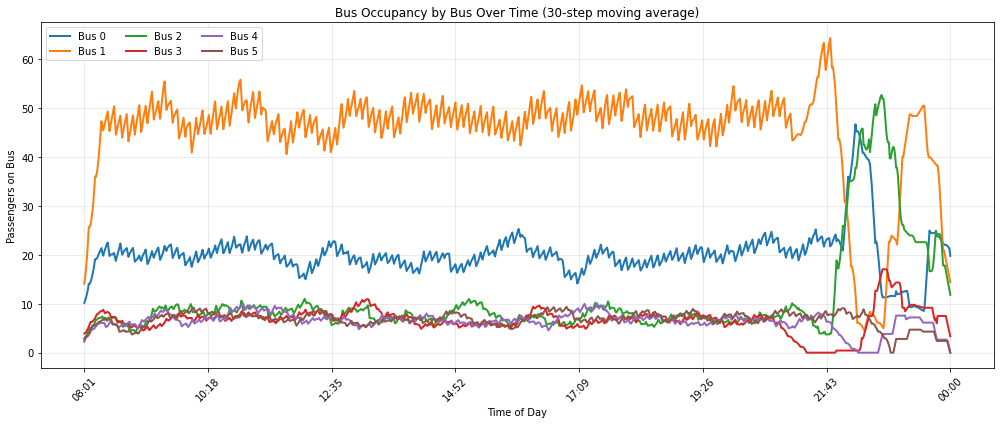

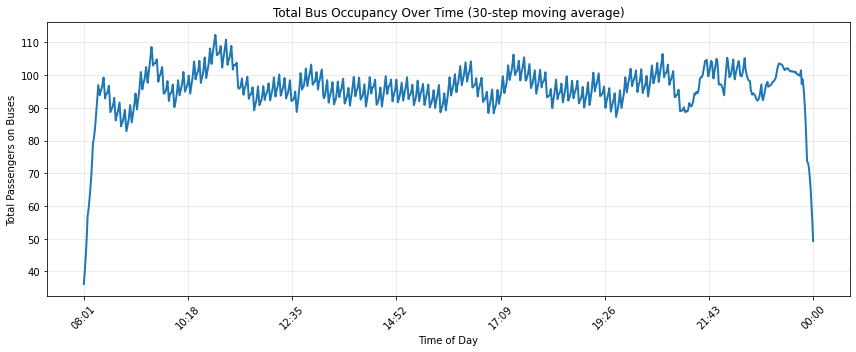

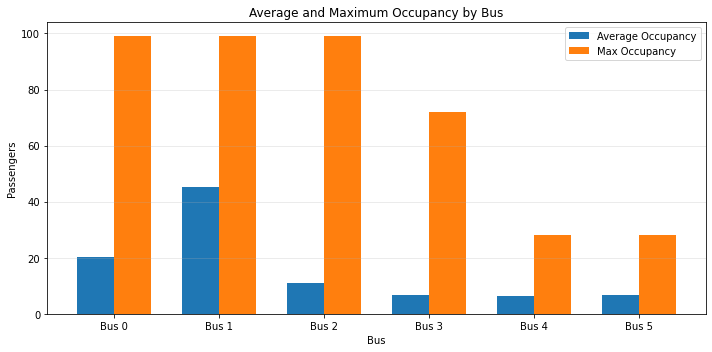

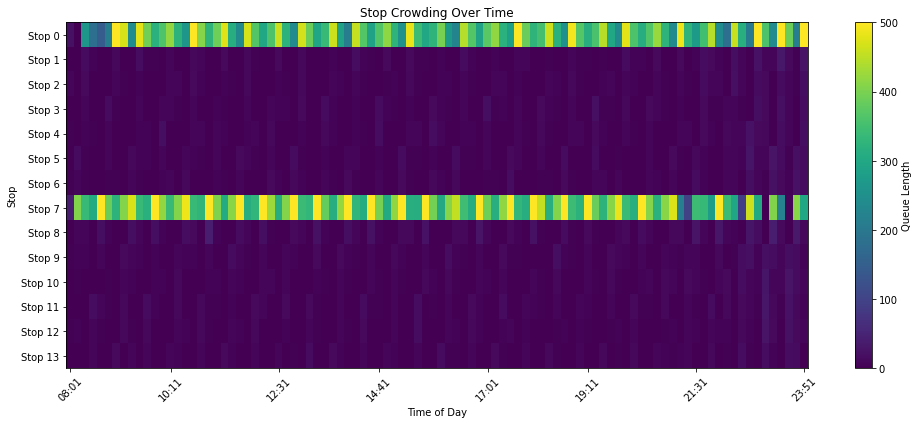

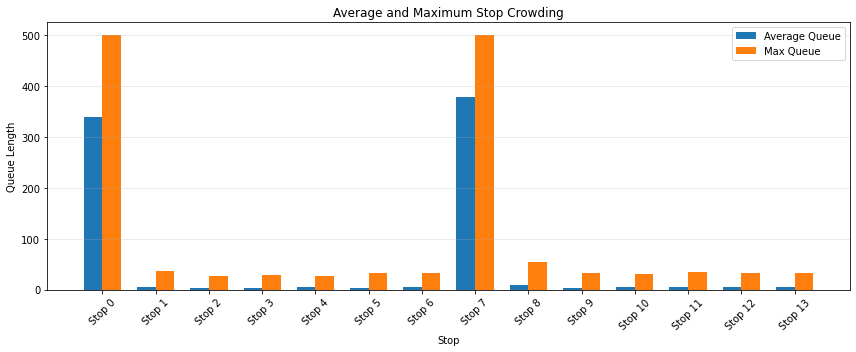

In [20]:
gym.register(
    id='gymnasium_env/BusRouting-v0',
    entry_point=BusEnv,
)

env = gym.make('gymnasium_env/BusRouting-v0')
agent = load_agent(env, MODEL_PATH)

logs, stop_crowding, bus_occupancy = run_episode(env, agent)
env.close()

save_logs(logs)

plot_bus_occupancy(bus_occupancy)
plot_total_bus_occupancy(bus_occupancy)
plot_bus_occupancy_summary(bus_occupancy)

plot_stop_crowding(stop_crowding)
plot_stop_crowding_summary(stop_crowding)